# EIA Petroleum Inventory Pipeline — WTI Crude Oil Direction Classification

This notebook builds the **EIA inventory feature pipeline** for use as alternative data in WTI direction prediction.

**Pipeline stages:**
1. **API Pull** — fetch 4 weekly series from EIA v2 API (Cushing stocks, total US crude, gasoline, distillates)
2. **Inspection** — check coverage, gaps, and basic statistics
3. **Alignment** — reindex weekly data to daily WTI trading calendar with forward-fill + 1-day lag (leakage prevention)
4. **Feature Engineering** — week-over-week changes, 4-week moving average, z-score, surprise (deviation from recent trend)
5. **Visualization** — time series plots and correlation with WTI direction
6. **Save** — write `data/eia_features_daily.csv` for use in model retraining notebooks

**Leakage note:** EIA reports are released every Wednesday ~10:30am ET for the week ending the prior Friday. After forward-filling into the daily calendar, we shift by 1 trading day so no prediction on day `t` uses information released on day `t`.

## 0. Setup

In [2]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

API_KEY = os.getenv("EIA_API_KEY", "dALTbSgR659ECRL65x1zLucViUT4PZDAo4XkjLLR")

# ── Paths ──
HERE       = Path(".")
DATA_DIR   = HERE / "data"
PRICE_FILE = HERE / ".." / "data" / "price" / "Price.csv"
OUT_CSV    = DATA_DIR / "eia_features_daily.csv"
RAW_CSV    = DATA_DIR / "eia_raw_weekly.csv"
DATA_DIR.mkdir(exist_ok=True)

START_DATE = "1983-01-01"   # matches WTI price history start
MAX_ROWS   = 5000           # EIA v2 API max per request (covers ~96 years of weekly data)

## 1. EIA API Pull

We query four series from the EIA v2 petroleum weekly stocks endpoint.

| Series ID | Description |
|-----------|-------------|
| `W_EPC0_SAX_YCUOK_MBBL` | Cushing, OK crude stocks — the WTI futures **physical delivery point**; most directly impacts WTI pricing |
| `WCSSTUS1` | Total U.S. commercial crude stocks (excl. Strategic Petroleum Reserve) |
| `WGTSTUS1` | Total U.S. gasoline stocks — demand proxy |
| `WDISTUS1` | Total U.S. distillate fuel stocks — demand proxy |

The Cushing number is the single most market-moving figure because WTI futures physically settle there. Results are cached to disk to avoid re-fetching on each run.

In [3]:
EIA_URL = "https://api.eia.gov/v2/petroleum/stoc/wstk/data/"

SERIES = {
    "cushing":  "W_EPC0_SAX_YCUOK_MBBL",
    "total_us": "WCSSTUS1",
    "gasoline": "WGTSTUS1",
    "distill":  "WDISTUS1",
}


def get_eia_series(series_id: str, start: str = START_DATE) -> pd.Series:
    """Fetch one EIA weekly series; return as a named Series indexed by week-ending date."""
    params = {
        "api_key":            API_KEY,
        "frequency":          "weekly",
        "data[0]":            "value",
        "facets[series][]": series_id,
        "start":              start,
        "sort[0][column]":    "period",
        "sort[0][direction]": "asc",
        "length":             MAX_ROWS,
    }
    resp = requests.get(EIA_URL, params=params, timeout=30)
    resp.raise_for_status()
    records = resp.json()["response"]["data"]
    if not records:
        raise ValueError(f"No data returned for series {series_id}")
    df = pd.DataFrame(records)
    df["period"] = pd.to_datetime(df["period"])
    df["value"]  = pd.to_numeric(df["value"], errors="coerce")
    return df.set_index("period")["value"].rename(series_id).sort_index()


def fetch_all_series(use_cache: bool = True) -> pd.DataFrame:
    """Pull all 4 series, join into a wide DataFrame, cache to disk."""
    if use_cache and RAW_CSV.exists():
        print(f"[CACHE] Loading {RAW_CSV}")
        return pd.read_csv(RAW_CSV, index_col=0, parse_dates=True)
    frames = []
    for name, sid in SERIES.items():
        print(f"Pulling {name} ({sid}) ...")
        s = get_eia_series(sid)
        s.name = name
        frames.append(s)
        time.sleep(0.3)
    raw = pd.concat(frames, axis=1)
    raw.to_csv(RAW_CSV)
    print(f"[SAVED] {RAW_CSV}  ({len(raw)} weekly observations)")
    return raw


raw_weekly = fetch_all_series()
print(f"\nDate range : {raw_weekly.index[0].date()} → {raw_weekly.index[-1].date()}")
print(f"Shape      : {raw_weekly.shape}")
raw_weekly.tail()

Pulling cushing (W_EPC0_SAX_YCUOK_MBBL) ...
Pulling total_us (WCSSTUS1) ...
Pulling gasoline (WGTSTUS1) ...
Pulling distill (WDISTUS1) ...
[SAVED] data\eia_raw_weekly.csv  (2255 weekly observations)

Date range : 1983-01-07 → 2026-04-10
Shape      : (2255, 4)


,cushing,total_us,gasoline,distill
period,,,,
2026-03-13,27524.0,415442,244040.0,116904
2026-03-20,30945.0,415442,241447.0,119936
2026-03-27,31465.0,415064,240861.0,117825
2026-04-03,31489.0,413325,239272.0,114681
2026-04-10,29762.0,409181,232944.0,111559


## 2. Raw Data Inspection

We check for missing values and temporal coverage of each series. Cushing data begins in 2004; the other three series go back to the early 1980s. Any gaps are noted before alignment.

In [4]:
raw_weekly = pd.read_csv(RAW_CSV, index_col=0, parse_dates=True)

summary = pd.DataFrame({
    "start":       raw_weekly.apply(lambda s: s.first_valid_index()),
    "end":         raw_weekly.apply(lambda s: s.last_valid_index()),
    "obs":         raw_weekly.count(),
    "missing":     raw_weekly.isna().sum(),
    "mean (Mbbl)": raw_weekly.mean().round(1),
    "std (Mbbl)":  raw_weekly.std().round(1),
})
print(summary.to_string())

              start        end   obs  missing  mean (Mbbl)  std (Mbbl)
cushing  2004-04-09 2026-04-10  1149     1106      35166.7     14422.4
total_us 1983-01-07 2026-04-10  2255        0     589533.3    103224.2
gasoline 1990-01-05 2026-04-10  1893      362     217353.6     15291.2
distill  1983-01-07 2026-04-10  2255        0     127093.7     18112.3


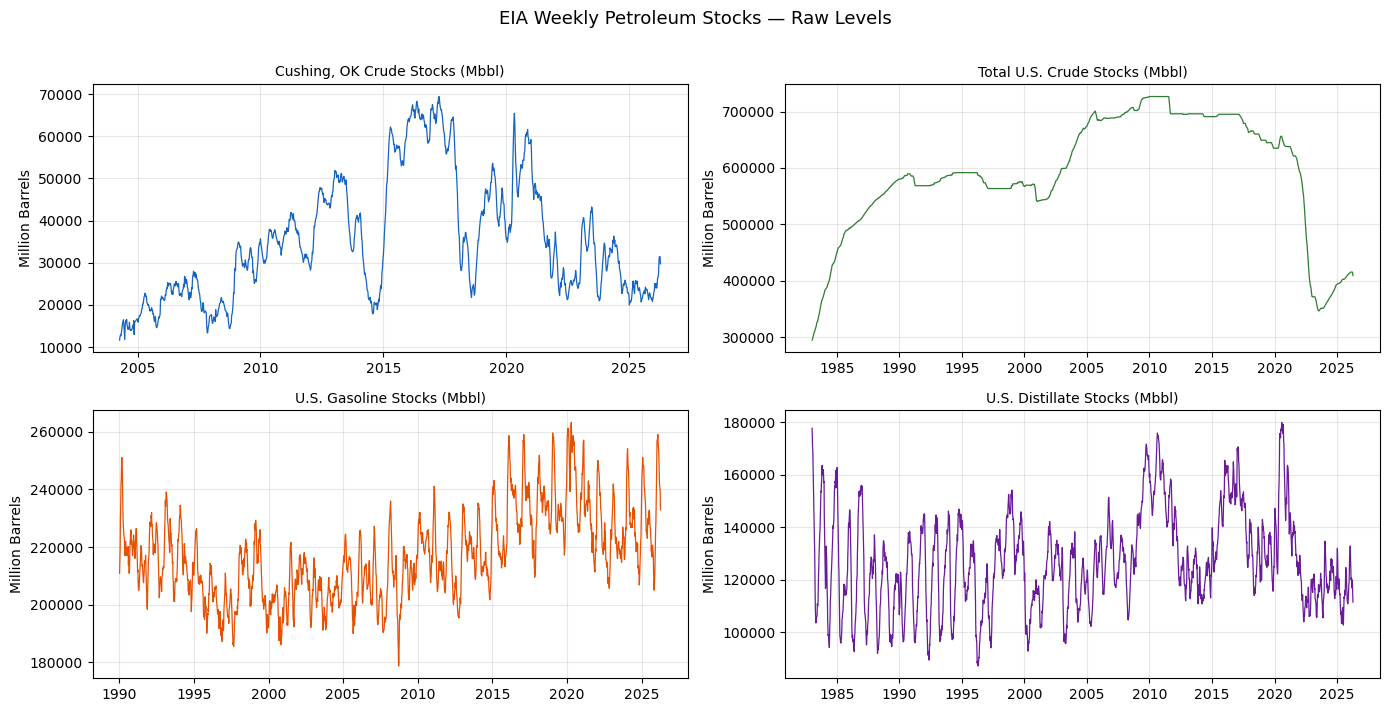

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
titles = {
    "cushing":  "Cushing, OK Crude Stocks (Mbbl)",
    "total_us": "Total U.S. Crude Stocks (Mbbl)",
    "gasoline": "U.S. Gasoline Stocks (Mbbl)",
    "distill":  "U.S. Distillate Stocks (Mbbl)",
}
colors = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A"]
for ax, (col, title), color in zip(axes.flat, titles.items(), colors):
    s = raw_weekly[col].dropna()
    ax.plot(s.index, s.values, linewidth=0.9, color=color)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Million Barrels")
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(alpha=0.3)
plt.suptitle("EIA Weekly Petroleum Stocks — Raw Levels", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Alignment to WTI Daily Trading Calendar

EIA releases are **weekly** (every Wednesday for the prior week). To merge with daily WTI prices we:
1. Load the WTI price series to get the authoritative daily trading-day index
2. `reindex` the weekly EIA data to that daily index — inserts `NaN` on non-release days
3. `ffill` to carry the last known inventory reading forward into each subsequent trading day
4. `shift(1)` — a 1-day lag so no prediction on day `t` uses information released on day `t`

The shift is conservative: even if the EIA report drops Wednesday morning, we do not use it until Thursday.

In [6]:
price = pd.read_csv(PRICE_FILE, parse_dates=["Date"]).set_index("Date")["Price"].sort_index()
print(f"WTI price range: {price.index[0].date()} → {price.index[-1].date()}  ({len(price)} days)")

# Align: reindex to daily calendar → forward-fill → lag by 1 day
eia_daily = raw_weekly.reindex(price.index, method="ffill").shift(1)

coverage = eia_daily.notna().sum()
print("\nTrading days with valid EIA data after alignment:")
print(coverage.to_string())

WTI price range: 1983-03-31 → 2025-10-31  (10835 days)

Trading days with valid EIA data after alignment:
cushing      5563
total_us    10834
gasoline     9136
distill     10834


## 4. Feature Engineering

Raw inventory levels contain a long-run trend (storage infrastructure has grown over decades) and are not stationary. We derive **stationary, market-relevant** features instead:

| Feature | Formula | Economic interpretation |
|---------|---------|------------------------|
| `cushing_chg` | `cushing.diff()` | Weekly build/draw at the WTI delivery point — most market-moving |
| `total_chg` | `total_us.diff()` | Broad U.S. supply signal |
| `gasoline_chg` | `gasoline.diff()` | Demand proxy: rising gasoline stocks → weak refinery demand |
| `distill_chg` | `distill.diff()` | Heating/diesel demand proxy |
| `cushing_4wma` | 4-week rolling mean of `cushing` | Smoothed level — medium-term supply pressure |
| `cushing_zscore` | `(cushing − 52w mean) / 52w std` | Seasonal-adjusted level relative to 1-year baseline |
| `surprise` | `cushing_chg − cushing_chg.rolling(4).mean()` | **Key feature**: inventory change minus recent average — captures deviation from consensus expectation |

The `surprise` feature is typically the most predictive because crude oil markets price in consensus expectations ahead of the Wednesday release. A larger-than-expected build (positive surprise) is bearish; an unexpected draw is bullish.

In [7]:
feat = pd.DataFrame(index=eia_daily.index)

feat["cushing_chg"]    = eia_daily["cushing"].diff()
feat["total_chg"]      = eia_daily["total_us"].diff()
feat["gasoline_chg"]   = eia_daily["gasoline"].diff()
feat["distill_chg"]    = eia_daily["distill"].diff()

feat["cushing_4wma"]   = eia_daily["cushing"].rolling(4,  min_periods=1).mean()
c52_mean               = eia_daily["cushing"].rolling(52, min_periods=26).mean()
c52_std                = eia_daily["cushing"].rolling(52, min_periods=26).std()
feat["cushing_zscore"] = (eia_daily["cushing"] - c52_mean) / c52_std.replace(0, np.nan)

feat["surprise"]       = feat["cushing_chg"] - feat["cushing_chg"].rolling(4, min_periods=1).mean()

print(f"Features : {list(feat.columns)}")
print(f"Shape    : {feat.shape}")
feat.describe().round(2)

Features : ['cushing_chg', 'total_chg', 'gasoline_chg', 'distill_chg', 'cushing_4wma', 'cushing_zscore', 'surprise']
Shape    : (10835, 7)


,cushing_chg,total_chg,gasoline_chg,distill_chg,cushing_4wma,cushing_zscore,surprise
count,5562.00,10833.00,9135.00,10833.00,5563.00,5538.00,5562.00
mean,1.96,9.12,-0.03,-1.71,35537.24,-0.02,0.00
std,558.44,493.62,1267.62,1213.53,14506.82,1.52,483.63
min,-5587.00,-8414.00,-13624.00,-13011.00,11677.00,-4.52,-4190.25
25%,0.00,0.00,0.00,0.00,23742.00,-1.34,-166.44
50%,0.00,0.00,0.00,0.00,33325.00,-0.07,0.00
75%,0.00,0.00,0.00,0.00,45574.12,1.28,164.75
max,6417.00,4510.00,11456.00,11205.00,69420.00,4.53,4812.75


## 5. Visualization

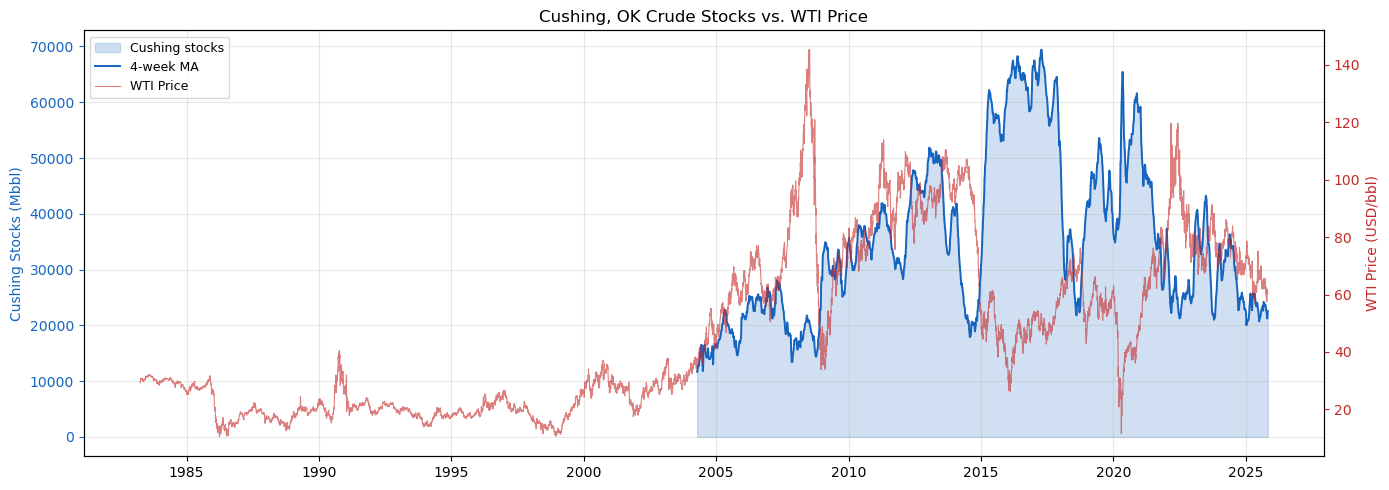

In [8]:
# Cushing stocks + 4-week MA vs. WTI price
fig, ax1 = plt.subplots(figsize=(14, 5))
s_cush = eia_daily["cushing"].dropna()
ax1.fill_between(s_cush.index, s_cush.values, alpha=0.2, color="#1565C0", label="Cushing stocks")
ax1.plot(s_cush.index, feat["cushing_4wma"].reindex(s_cush.index),
         color="#1565C0", linewidth=1.4, label="4-week MA")
ax1.set_ylabel("Cushing Stocks (Mbbl)", color="#1565C0")
ax1.tick_params(axis="y", colors="#1565C0")

ax2 = ax1.twinx()
ax2.plot(price.index, price.values, color="#C62828", linewidth=0.8, alpha=0.6, label="WTI Price")
ax2.set_ylabel("WTI Price (USD/bbl)", color="#C62828")
ax2.tick_params(axis="y", colors="#C62828")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
ax1.set_title("Cushing, OK Crude Stocks vs. WTI Price", fontsize=12)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

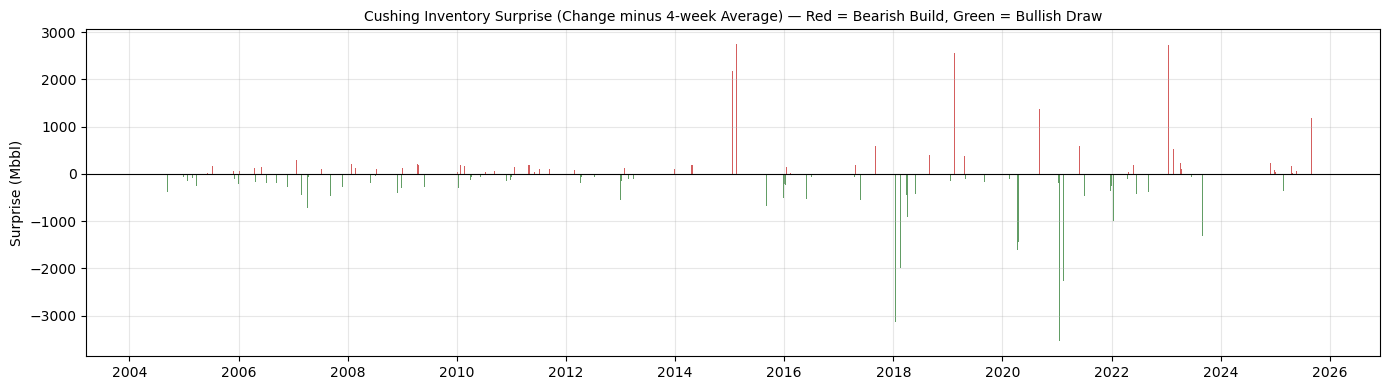

In [9]:
# Surprise feature — weekly bars (red = bearish build, green = bullish draw)
surprise_weekly = feat["surprise"].resample("W").last().dropna()
fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#C62828" if v > 0 else "#2E7D32" for v in surprise_weekly]
ax.bar(surprise_weekly.index, surprise_weekly.values, width=5, color=colors, alpha=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Surprise (Mbbl)")
ax.set_title("Cushing Inventory Surprise (Change minus 4-week Average) — Red = Bearish Build, Green = Bullish Draw", fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

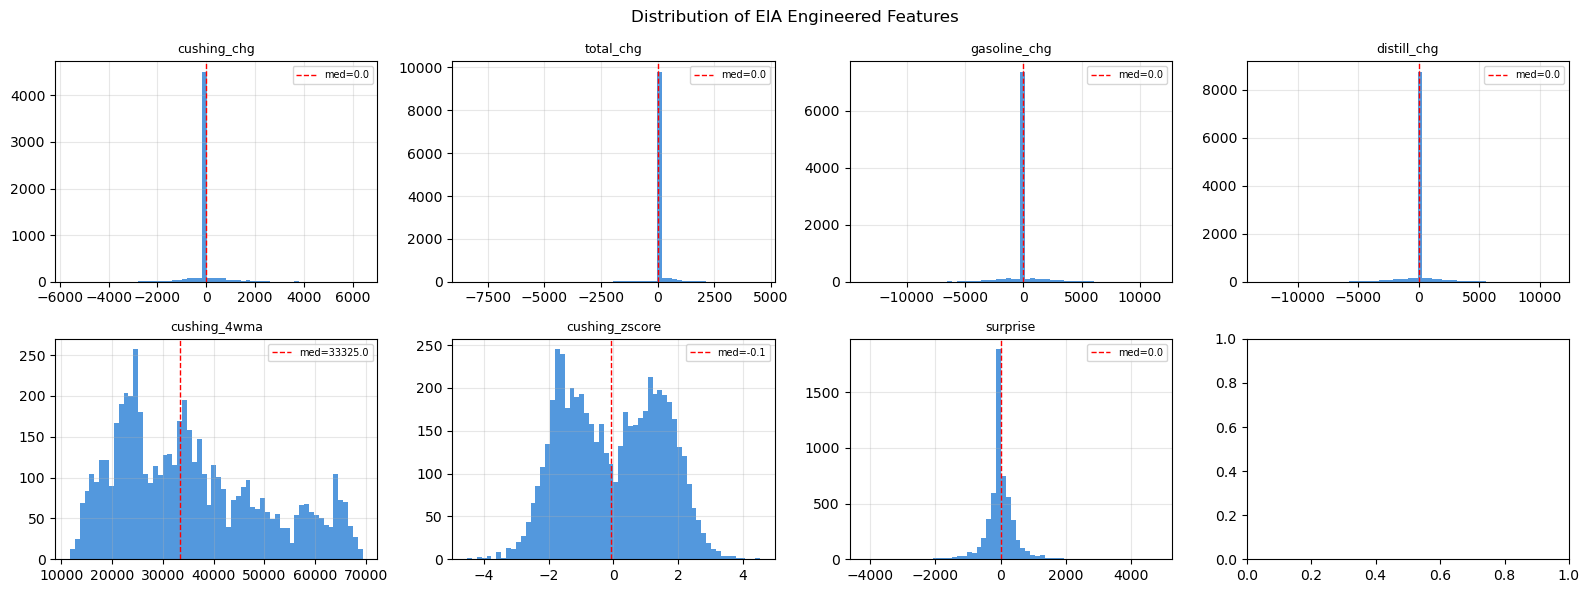

In [10]:
# Distribution of all engineered features
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, feat.columns):
    vals = feat[col].dropna()
    ax.hist(vals, bins=60, color="#1976D2", alpha=0.75, edgecolor="none")
    ax.axvline(vals.median(), color="red", linewidth=1, linestyle="--", label=f"med={vals.median():.1f}")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.suptitle("Distribution of EIA Engineered Features", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Correlation with WTI Direction

We compute Pearson correlations between each EIA feature and the **next-day WTI direction** (1 = up, 0 = down). Low absolute correlations are expected — crude oil direction is inherently noisy — but statistically significant values, especially for `surprise`, support inclusion as features. The `surprise` feature should show a negative correlation: a positive surprise (unexpected inventory build) predicts a down day.

Pearson correlation with next-day WTI direction (1=up, 0=down):
surprise          0.0187
cushing_4wma      0.0183
total_chg        -0.0171
cushing_zscore   -0.0148
gasoline_chg     -0.0096
cushing_chg      -0.0024
distill_chg      -0.0000


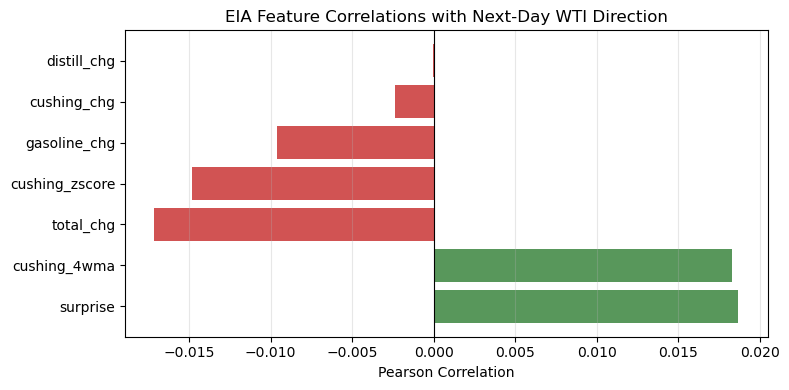

In [11]:
direction = (price.diff() > 0).astype(int).rename("direction")
corr_df   = feat.join(direction).dropna()
corrs     = corr_df.drop(columns="direction").corrwith(corr_df["direction"]).sort_values(key=abs, ascending=False)

print("Pearson correlation with next-day WTI direction (1=up, 0=down):")
print(corrs.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2E7D32" if v > 0 else "#C62828" for v in corrs]
ax.barh(corrs.index, corrs.values, color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation")
ax.set_title("EIA Feature Correlations with Next-Day WTI Direction")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Coverage Over Time

The Cushing series (`W_EPC0_SAX_YCUOK_MBBL`) begins in **2004**; the other three series go back to the early 1980s. Model retraining notebooks handle this by allowing NaNs for the Cushing-derived features pre-2004 — tree models (XGBoost) handle missing values natively; linear models and LSTM use zero-imputation with a binary indicator flag.

In [12]:
cov_table = pd.DataFrame({
    "first_valid":  feat.apply(lambda s: s.first_valid_index()),
    "last_valid":   feat.apply(lambda s: s.last_valid_index()),
    "coverage_%":   (feat.notna().sum() / len(feat) * 100).round(1),
    "nan_count":    feat.isna().sum(),
})
print(cov_table.to_string())

               first_valid last_valid  coverage_%  nan_count
cushing_chg     2004-04-14 2025-10-31        51.3       5273
total_chg       1983-04-05 2025-10-31       100.0          2
gasoline_chg    1990-01-09 2025-10-31        84.3       1700
distill_chg     1983-04-05 2025-10-31       100.0          2
cushing_4wma    2004-04-13 2025-10-31        51.3       5272
cushing_zscore  2004-05-18 2025-10-31        51.1       5297
surprise        2004-04-14 2025-10-31        51.3       5273


## 8. Save

The final feature matrix is saved to `data/eia_features_daily.csv`. Each row is one WTI trading day. Model retraining notebooks load this file and join it to the standard FRED-MD + price lag feature matrix on the `Date` index.

**Columns saved:** `cushing_chg`, `total_chg`, `gasoline_chg`, `distill_chg`, `cushing_4wma`, `cushing_zscore`, `surprise`

In [13]:
feat.index.name = "Date"
feat.to_csv(OUT_CSV)
print(f"Saved : {OUT_CSV}")
print(f"Shape : {feat.shape}")
print(f"Range : {feat.index[0].date()} → {feat.index[-1].date()}")
print(f"\nNaN counts:")
print(feat.isna().sum().to_string())

Saved : data\eia_features_daily.csv
Shape : (10835, 7)
Range : 1983-03-31 → 2025-10-31

NaN counts:
cushing_chg       5273
total_chg            2
gasoline_chg      1700
distill_chg          2
cushing_4wma      5272
cushing_zscore    5297
surprise          5273


## Summary

| Stage | Output |
|-------|--------|
| EIA API pull (4 weekly series from 1983) | `data/eia_raw_weekly.csv` |
| Aligned to daily trading calendar + 1-day lag | `eia_daily` DataFrame |
| 7 engineered features (changes, MA, z-score, surprise) | `feat` DataFrame |
| Saved to disk | `data/eia_features_daily.csv` |

**Next step:** Load `data/eia_features_daily.csv` in model retraining notebooks and join to the FRED-MD + price lag feature matrix. Train each model with and without EIA features to measure the incremental predictive value.